<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Lecture 4: Sequence Models

**University of Maryland, College Park**  
**Fall 2025**  
**Instructor**: Armin Mehrabian  
**Date**: September 22–23, 2025  



<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 1. Probabilistic Language Models



# Probabilistic Language Models  

**Goal:** Use probability to decide which sentence is more natural.  


**Applications**  

- **Machine Translation:**  
  $P(\text{strong rain tomorrow}) > P(\text{big rain tomorrow})$  

- **Spell Checking:**  
  *She wants to eat **desert***  
  - $P(\text{eat dessert}) > P(\text{eat desert})$  

- **Speech Recognition:**  
  $P(\text{recognize speech}) \gg P(\text{wreck a nice beach})$  



# Probabilistic Language Modeling (1/2)  

**Goal:**  
Compute the probability of a sentence or sequence of words:  

$$
P(W) = P(w_1, w_2, w_3, \dots, w_n)
$$  


# Probabilistic Language Modeling (2/2)  

**Related task:**  
Compute the probability of the next word given the history:  

$$
P(w_{t} \mid w_1, w_2, \dots, w_{t-1})
$$  

**Definition:**  
A model that estimates either $P(W)$ or $P(w_t \mid w_1, \dots, w_{t-1})$ is called a **language model (LM)**.  

*Note:* In linguistics the term *grammar* is often used, but in NLP the standard term is **language model**.


# How to Compute $P(W)$  

**Question:** How do we calculate the probability of an entire sentence?  

Example joint probability:  

$$
P(\text{the}, \text{cat}, \text{sat}, \text{on}, \text{the}, \text{mat})
$$  

**Intuition:**  
We rely on the **Chain Rule of Probability** to decompose this joint probability into a sequence of conditional probabilities.


# Reminder: Conditional Probability  

**Definition:**  

$$
P(A \mid B) = \frac{P(A, B)}{P(B)}
$$  

Rearranged:  

$$
P(A, B) = P(A \mid B) \, P(B)
$$  


# Reminder: The Chain Rule  

For multiple variables:  

$$
P(A, B, C, D) = P(A) \, P(B \mid A) \, P(C \mid A, B) \, P(D \mid A, B, C)
$$  

**In general:**  

$$
P(x_1, x_2, \dots, x_n) = \prod_{t=1}^n P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$  


# The Chain Rule for Sentence Probability  

The joint probability of a sequence of words can be decomposed using the **Chain Rule of Probability**:  

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, w_2, \dots, w_{i-1})
$$  


**Example:**  

For the sentence *"the cat sat down"*  

$$
P(\text{the cat sat down}) = P(\text{the}) \times P(\text{cat} \mid \text{the}) \times P(\text{sat} \mid \text{the cat}) \times P(\text{down} \mid \text{the cat sat})
$$


# Parameter Growth

The generative process quickly becomes complex:  

- $P(w_1)$ requires $O(V)$ parameters  
- $P(w_2 \mid w_1)$ requires $O(V^2)$ parameters  
- $P(w_3 \mid w_1, w_2)$ requires $O(V^3)$ parameters  

Here, $V$ is the size of the vocabulary.  


# How to Estimate Probabilities  

**Idea:** Could we just count and divide?  

Example:  

$$
P(\text{sat} \mid \text{the cat}) 
= \frac{\text{Count}(\text{the cat sat})}{\text{Count}(\text{the cat})}
$$  


**Problem:**  
This method is simple, but there are **too many possible sentences**.  
Most sequences will be unseen in real data.


In [1]:
import nltk
from nltk.corpus import brown
from collections import Counter

# Download corpus if not already
nltk.download("brown")

# Use the
tokens = brown.words()

# Build bigrams
bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]

# Count frequencies
unigram_counts = Counter(tokens)
bigram_counts = Counter(bigrams)

# Example: P(man | the)
num = bigram_counts[("the", "man")]
den = unigram_counts["the"]
prob = num / den if den > 0 else 0

print("P(man | the) =", prob)


[nltk_data] Error loading brown: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


P(man | the) = 0.002041044121633473


# Estimating from a Real Corpus  

We can compute probabilities directly from counts in a large corpus.  

**Example (Brown corpus):**  

$$
P(\text{man} \mid \text{the}) 
= \frac{\text{Count}(\text{the man})}{\text{Count}(\text{the})}
\approx 0.002
$$  

**Observation:**  
Even in a large corpus, many reasonable phrases have **very low probabilities**.  
This highlights the **sparsity problem** in language modeling.


# Markov Models (1/2)  

**Key idea:** The **Markov property** assumes that the future depends only on a limited history, not the entire past.  

- **First-order Markov assumption:**  
  $$
  P(w_i \mid w_1, w_2, \dots, w_{i-1}) \;\approx\; P(w_i \mid w_{i-1})
  $$  

- **Bigram model** = first-order Markov approximation  

- This simplification treats the **previous word** as a summary (equivalence class) of all possible histories that end with it.  


# The Simplest Case: Unigram Model  

**Unigram assumption:**  
Each word is chosen independently of the others.  

$$
P(w_1, w_2, \dots, w_n) \;\approx\; \prod_{i=1}^{n} P(w_i)
$$  


**Example: Generated text from a unigram model**  

- *dog, is, a, sat, happy, on, mat*  
- *house, big, the, tree, runs, cat*  


**Observation:**  
- The words are **grammatical individually**, but the sequence is **nonsensical**.  
- This shows that **unigram models ignore context**.  


In [2]:
import random
from collections import Counter, defaultdict
from nltk.corpus import brown

# Use the full Brown corpus
tokens = brown.words()

def build_ngram_model(tokens, order=1):
    """
    Build an n-gram language model of given order.
    
    Parameters:
    - tokens: list of words from the corpus
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    
    Returns:
    - followers: dictionary mapping context → list of next words
    """
    ngrams = [tuple(tokens[i:i+order+1]) for i in range(len(tokens) - order)]
    ngram_counts = Counter(ngrams)

    followers = defaultdict(list)
    for ngram, count in ngram_counts.items():
        context, next_word = ngram[:-1], ngram[-1]
        followers[context].extend([next_word] * count)

    return followers

def generate_sentence(followers, order=1, length=10, start=None):
    """
    Generate a sentence using an n-gram model.
    
    - followers: trained model
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    - length: number of words to generate
    - start: optional start word/tuple. If None, chosen randomly.
    """
    # Pick a valid random start if none provided
    if start is None:
        start = random.choice(list(followers.keys()))
    
    # Ensure start is a tuple
    if not isinstance(start, tuple):
        start = (start,)
    
    # If start length doesn't match order, replace with random context
    if len(start) != order:
        start = random.choice(list(followers.keys()))
    
    # Begin sentence
    sentence = list(start)

    for _ in range(length - len(start)):
        context = tuple(sentence[-order:]) if order > 0 else tuple()
        if context not in followers:
            break
        next_word = random.choice(followers[context])
        sentence.append(next_word)

    return " ".join(sentence)

# -----------------
# Example usage:
# -----------------

# Change order here: 0=unigram, 1=bigram, 2=trigram, etc.
order = 0
model = build_ngram_model(tokens, order=order)

# Generate a sample sentence
print(generate_sentence(model, order=order, length=15))


process Dutch . April U.S. from down to , and mode Perhaps could I one


# Markov Model (2/2)  

**Bigram probability of a sequence:**  

$$
P_{\text{bigram}}(w_0, w_1, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_{i-1})
$$  


**In log space:**  

$$
\log P(w_1, \dots, w_n) = \sum_{i=1}^{n} \log P(w_i \mid w_{i-1})
$$  


**Why logs?**  
- Avoids numerical underflow (very small probabilities).  
- Turns multiplication into addition (faster, more stable).  
 


# Special START Token  

**Problem:**  
- In bigram models, the first word $w_1$ has no previous context.  
- Without a fix, $P(w_1 \mid w_{0})$ is undefined.  



**Solution:**  
Introduce a special token:  

- $w_0 = \langle \text{START} \rangle$  
- $P(w_0) = 1$ (certain)  

So the sequence probability becomes:  

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_{i-1})
$$  

with $w_0 = \langle \text{START} \rangle$.  



**Why this matters:**  
- Ensures a **uniform formula** for every word.  
- Teaches the model what words typically begin a sentence.  



**Connection to modern LLMs:**  
- Today’s models also use special tokens:  
  - $\langle \text{BOS} \rangle$, $\langle \text{EOS} \rangle$ for sentence boundaries  
  - $\langle \text{PAD} \rangle$, $\langle \text{MASK} \rangle$, `<CLS>`, `<SEP>` for tasks  
- Idea originated with these early **Markov/N-gram models**.  


In [3]:
import random
from collections import Counter, defaultdict
from nltk.corpus import brown

# Use the full Brown corpus
tokens = brown.words()

def build_ngram_model(tokens, order=1):
    """
    Build an n-gram language model of given order.
    
    Parameters:
    - tokens: list of words from the corpus
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    
    Returns:
    - followers: dictionary mapping context → list of next words
    """
    ngrams = [tuple(tokens[i:i+order+1]) for i in range(len(tokens) - order)]
    ngram_counts = Counter(ngrams)

    followers = defaultdict(list)
    for ngram, count in ngram_counts.items():
        context, next_word = ngram[:-1], ngram[-1]
        followers[context].extend([next_word] * count)

    return followers

def generate_sentence(followers, order=1, length=10, start=None):
    """
    Generate a sentence using an n-gram model.
    
    - followers: trained model
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    - length: number of words to generate
    - start: optional start word/tuple. If None, chosen randomly.
    """
    # Pick a valid random start if none provided
    if start is None:
        start = random.choice(list(followers.keys()))
    
    # Ensure start is a tuple
    if not isinstance(start, tuple):
        start = (start,)
    
    # If start length doesn't match order, replace with random context
    if len(start) != order:
        start = random.choice(list(followers.keys()))
    
    # Begin sentence
    sentence = list(start)

    for _ in range(length - len(start)):
        context = tuple(sentence[-order:]) if order > 0 else tuple()
        if context not in followers:
            break
        next_word = random.choice(followers[context])
        sentence.append(next_word)

    return " ".join(sentence)

# -----------------
# Example usage:
# -----------------

# Change order here: 0=unigram, 1=bigram, 2=trigram, etc.
order = 2
model = build_ngram_model(tokens, order=order)

# Generate a sample sentence
print(generate_sentence(model, order=order, length=15))


determine present and future evil . He never smiled . `` I've got this cold


In [4]:
# ============================================================
# Exercise: Comparing Text Quality Across N-gram Orders
# ============================================================
# Run this cell AFTER Cell 20 has been executed so that
# build_ngram_model and generate_sentence are available.
# Notice how generated text becomes more locally coherent
# as we increase the order — but long-range structure is still missing.

import random
random.seed(42)

print("=" * 60)
print("  Generated text by N-gram order (Brown corpus)")
print("=" * 60)

for order, name in [(0, "Unigram (independent words)"),
                    (1, "Bigram  (1-word context)"),
                    (2, "Trigram (2-word context)")]:
    model = build_ngram_model(tokens, order=order)
    print(f"\n--- {name} ---")
    for _ in range(3):
        sent = generate_sentence(model, order=order, length=14)
        print(f"  · {sent}")

print()
print("Observation: Trigrams produce more fluent local phrases, but")
print("  long-distance grammar (subject-verb agreement, etc.) is still broken.")
print("  This is the fundamental limitation of fixed-window N-gram models.")


  Generated text by N-gram order (Brown corpus)



--- Unigram (independent words) ---
  · `` John from This and , portfolio-maker the Would '' '' the Legislature with
  · them Sixties Philadelphia at coffee make of by boy College wanted was as development
  · the Very the absolute skills back . concentration geocentric , ; the Delphine A



--- Bigram  (1-word context) ---
  · Homes and Af , damp , the ritual generated by the rupees accruing under
  · wedding cake . That girl '' . This dish much lower than thirty days
  · Federico Garcia , called , on C and made -- in such diverse reasons



--- Trigram (2-word context) ---
  · physiological agent ( ATP ) responsible for his first `` recital '' only rises
  · come down in bickering . Even so , we made it impossible to the
  · except those few there was much to learn that a reduction in the apartment

Observation: Trigrams produce more fluent local phrases, but
  long-distance grammar (subject-verb agreement, etc.) is still broken.
  This is the fundamental limitation of fixed-window N-gram models.


# N-gram Models: Limitations  

- We can extend to trigrams, 4-grams, 5-grams, etc.  
- But in general, this is still an **insufficient model of language**  
  - because natural language often has **long-distance dependencies**  


**Example:**  

*"The book that the professor recommended during the seminar was fascinating."*  

- The word *"book"* (subject) connects to *"was fascinating"* (verb + predicate).  
- An N-gram model with only short context may fail to capture this relationship.  


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 2. Language Model Evaluation



# Extrinsic Evaluation of Language Models  

**Best way to compare models A and B:** test them in a **real application**  

- Examples: spelling correction, speech recognition, machine translation, question answering, summarization  
- Run the task, measure accuracy for A and for B  
  - How many misspelled words corrected properly?  
  - How many words translated correctly?  

**A/B testing = extrinsic evaluation with real users**  
- Instead of offline benchmarks, deploy A and B to different user groups  
- Compare real-world metrics (engagement, satisfaction, revenue)  



# Language Model Evaluation (1/2)  

**What makes a good language model (LM)?**  
It assigns high probability to sentences in the test set.  

---

- **Goal:**  
  Estimate $P_{\text{LM}}$ from training data, and then evaluate on **unseen test data $W$**.  

- **Perplexity:**  
  A measure of how "surprised" the model is when it encounters the test data.  

- **Interpretation:**  
  Lower perplexity = better performance.  


Extrinsic evaluation is about judging models by **their impact on actual tasks**, not just by abstract metrics like perplexity.  


# Intrinsic Evaluation of Language Models  

**Definition:**  
Evaluate the model by comparing its predictions directly against held-out test data.  



**Characteristics:**  
- Uses a **standalone metric** (no downstream task).  
- Fast, cheap, easy to compute.  
- Provides a quick **proxy for model quality**.  


**Examples of intrinsic metrics:**  
- **Perplexity** (how well the model predicts sequences).  
- **Cross-entropy / log-likelihood** (used for training & evaluation).  

 
Intrinsic evaluation is about measuring the model’s **predictive power** directly,  
without embedding it into an application.  


# Language Model Evaluation: Perplexity  

**Definition**  
Perplexity quantifies how well a language model predicts a sequence of text.  

For a sequence $w = (w_1, w_2, \dots, w_N)$:  

$$
PP(w) = \sqrt[N]{\frac{1}{P(w)}} 
       = \exp\left(-\frac{1}{N}\sum_{i=1}^N \log P(w_i \mid \text{context})\right)
$$

where:  
- $w_i$ = the $i$-th word in the sequence  
- $N$ = the total number of words (tokens) in the sequence  


# Language Model Evaluation: Perplexity (cont.)  

**Interpretation**  
- Measures the model’s **average branching factor**  
- **Lower perplexity → better predictions** (less "surprise")  
- Reported for n-gram models, RNNs, and modern LMs  

**Key Insight**  
- Perplexity is an **intrinsic evaluation metric** (fast to compute)  
- Lower perplexity does **not always** mean better performance on downstream tasks  


# Perplexity with a Uniform Distribution

**Setup:**  
- Vocabulary = {zero, one, two, …, nine}  
- Size of vocabulary = 10 words  
- Model $M$ is **uniform**: every word has probability $1/10$  



**Sentence probability:**  
For a sequence $W$ of $N$ words:  

$$
P(W) = \left(\frac{1}{10}\right)^N
$$  



**Perplexity:**  

$$
PP(W) = \left(\frac{1}{P(W)}\right)^{1/N}  
= \left(\frac{1}{(1/10)^N}\right)^{1/N}  
= 10
$$  


  
For a uniform model, perplexity = **vocabulary size** (independent of sentence length).  

# Perplexity with a 1-word context (bigram)

**Corpus:**  
*"the cat sat"*  
*"the cat ran"*  
*"the dog barked"*  


**Step 1: Count frequencies**  
- Count(the) = 3  
- Count(cat) = 2, Count(dog) = 1  
- Count(the, cat) = 2  
- Count(the, dog) = 1  



**Step 2: Estimate conditional probabilities**  

$$
P(\text{cat} \mid \text{the}) = \frac{2}{3} \quad ; \quad
P(\text{dog} \mid \text{the}) = \frac{1}{3}
$$  



**Step 3: Compute perplexity (N=2)**  

For *"the cat"* :  

$$
P(\text{the cat}) = P(\text{the}) \times P(\text{cat} \mid \text{the})
= \frac{3}{6} \times \frac{2}{3} = \frac{1}{3}
$$  

$$
PP = \left(\frac{1}{1/3}\right)^{1/2} = \sqrt{3} \approx 1.73
$$  

For *"the dog"* :  

$$
P(\text{the dog}) = P(\text{the}) \times P(\text{dog} \mid \text{the})
= \frac{3}{6} \times \frac{1}{3} = \frac{1}{6}
$$  

$$
PP = \left(\frac{1}{1/6}\right)^{1/2} = \sqrt{6} \approx 2.45
$$  
  



**Interpretation:**  
- Lower perplexity for *"the cat"* → model is **less surprised**.  
- Higher perplexity for *"the dog"* → model is **more surprised**.

In [5]:
# import math
# from collections import Counter, defaultdict
# from nltk.corpus import brown
# import nltk

# nltk.download("brown")

# --------------------------
# Step 1: Preprocess corpus
# --------------------------

# Use sentence tokenization, add START/END tokens
sents = brown.sents()
tokens = []
for s in sents:
    tokens.extend(["<START>"] + list(s) + ["<END>"])

# --------------------------
# Step 2: Build unigram model
# --------------------------

unigram_counts = Counter(tokens)
total_unigrams = sum(unigram_counts.values())

def unigram_prob(word):
    """Return P(word) under unigram model"""
    return unigram_counts[word] / total_unigrams

# --------------------------
# Step 3: Build bigram model
# --------------------------

bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]
bigram_counts = Counter(bigrams)

# For convenience, also keep unigram counts (already built)
def bigram_prob(w2, w1):
    """Return P(w2 | w1) under bigram model"""
    if unigram_counts[w1] == 0:
        return 0
    return bigram_counts[(w1, w2)] / unigram_counts[w1]

# --------------------------
# Step 4: Sentence probability
# --------------------------

def prob_sentence_unigram(sentence):
    """
    Compute probability of a sentence under unigram model
    sentence: list of words (without START/END)
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for w in words:
        p *= unigram_prob(w)
    return p

def prob_sentence_bigram(sentence):
    """
    Compute probability of a sentence under bigram model
    sentence: list of words (without START/END)
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for i in range(1, len(words)):
        p *= bigram_prob(words[i], words[i-1])
    return p

# --------------------------
# Step 5: Perplexity
# --------------------------

def perplexity(prob, N):
    """
    Compute perplexity from sentence probability
    prob: sentence probability
    N: number of words in the sentence (excluding START/END)
    """
    if prob == 0:
        return float("inf")
    return (1/prob) ** (1/N)

# --------------------------
# Example
# --------------------------

sentence = ["the", "cat", "sat"]

p_uni = prob_sentence_unigram(sentence)
p_bi = prob_sentence_bigram(sentence)

print("Unigram probability:", p_uni)
print("Bigram probability:", p_bi)

print("Unigram perplexity:", perplexity(p_uni, len(sentence)))
print("Bigram perplexity:", perplexity(p_bi, len(sentence)))


Unigram probability: 1.9991545513791433e-13
Bigram probability: 0.0
Unigram perplexity: 17102.169640701308
Bigram perplexity: inf


# Data Sparsity in N-gram Models  

**Problem**  
- Many valid sequences never appear in training data  
- Example: "the cat sat" may not occur → $P(\text{sat} \mid \text{cat}) = 0$  
- Then $P(\text{sentence}) = 0$ → $PP = \infty$  

**Remedy: Smoothing**  
- Reserve some probability mass for unseen events  
- Ensures all continuations have non-zero probability  

**Add-1 (Laplace) smoothing**  

$$
P(w_i \mid w_{i-1}) = \frac{\text{Count}(w_{i-1}, w_i) + 1}
                           {\text{Count}(w_{i-1}) + V}
$$  

where $V$ = vocabulary size  

**Effect**  
- Frequent events lose a little probability  
- Unseen events become possible (non-zero probability)  


In [6]:
# Add-1 smoothing for bigrams

V = len(unigram_counts)  # vocabulary size

def bigram_prob_smoothed(w2, w1):
    """
    Add-1 smoothed bigram probability:
    P(w2 | w1) = (Count(w1, w2) + 1) / (Count(w1) + V)
    """
    return (bigram_counts[(w1, w2)] + 1) / (unigram_counts[w1] + V)

def prob_sentence_bigram_smoothed(sentence):
    """
    Probability of a sentence with Add-1 smoothing.
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for i in range(1, len(words)):
        p *= bigram_prob_smoothed(words[i], words[i-1])
    return p

# Example: "the cat sat"
sentence = ["the", "cat", "sat"]
p_bi_smoothed = prob_sentence_bigram_smoothed(sentence)
pp_bi_smoothed = perplexity(p_bi_smoothed, len(sentence))

print("Smoothed bigram probability:", p_bi_smoothed)
print("Smoothed bigram perplexity:", pp_bi_smoothed)


Smoothed bigram probability: 5.177147186418028e-17
Smoothed bigram perplexity: 268309.7755374276


## Better Smoothing: Kneser-Ney

**Add-1 (Laplace) smoothing** is simple but crude — it gives the same extra probability to every unseen word, regardless of how versatile that word is.

**Kneser-Ney smoothing** is the empirically best-performing classical smoothing method and the default in industrial toolkits like KenLM and SRILM.

---

### Core Idea: Continuation Probability

For the backoff term, instead of raw word frequency, Kneser-Ney uses the **number of distinct left-contexts** a word appears with:

$$P_{\text{cont}}(w) \;\propto\; |\{v : C(v,\, w) > 0\}|$$

**Intuition:**  
- *"Francisco"* is frequent, but almost always follows *"San"* → low backoff probability.  
- *"room"* follows many different words (hotel room, living room, classroom…) → high backoff probability.

---

### Interpolated Kneser-Ney (bigram):

$$P_{\text{KN}}(w_i \mid w_{i-1}) \;=\; \frac{\max\bigl(C(w_{i-1}, w_i) - d,\; 0\bigr)}{C(w_{i-1})} \;+\; \lambda(w_{i-1}) \cdot P_{\text{cont}}(w_i)$$

| Symbol | Meaning |
|--------|---------|
| $d \approx 0.75$ | Discount subtracted from all observed bigram counts |
| $\lambda(w_{i-1})$ | Normalisation constant that redistributes the discounted mass |
| $P_{\text{cont}}(w_i)$ | Continuation probability (lower-order distribution) |

> **Kneser-Ney is the standard** for classical n-gram LMs. Neural language models (GPT, BERT, etc.) implicitly learn even smoother representations through gradient descent, but KN remains a strong baseline.


In [7]:
# ============================================================
# Kneser-Ney Smoothing — implemented from scratch
# Relies on unigram_counts and bigram_counts built in Cell 38
# ============================================================
from collections import defaultdict

# ── Step 1: Continuation counts ────────────────────────────────────────
# For each word w2, track every distinct left-context w1 it appears with.
left_contexts  = defaultdict(set)   # left_contexts[w2]  = set of w1
right_contexts = defaultdict(set)   # right_contexts[w1] = set of w2

for (w1, w2) in bigram_counts:
    left_contexts[w2].add(w1)
    right_contexts[w1].add(w2)

total_bigram_types = len(bigram_counts)   # denominator for P_cont

def p_continuation(w):
    """Continuation probability: fraction of distinct bigram types ending in w."""
    return len(left_contexts[w]) / (total_bigram_types + 1e-10)

# ── Step 2: Kneser-Ney bigram probability ──────────────────────────────
d = 0.75   # standard discount (typically tuned on a dev set)

def p_kn_bigram(w2, w1):
    """Interpolated Kneser-Ney P(w2 | w1)."""
    c_w1_w2 = bigram_counts.get((w1, w2), 0)
    c_w1    = unigram_counts.get(w1, 0)
    if c_w1 == 0:
        return p_continuation(w2)
    p_disc = max(c_w1_w2 - d, 0) / c_w1
    n_types_after_w1 = len(right_contexts[w1])
    lam = (d * n_types_after_w1) / c_w1
    return p_disc + lam * p_continuation(w2)

# ── Step 3: Compare Laplace vs Kneser-Ney ──────────────────────────────
# Key insight: KN boosts versatile words (many left-contexts)
# and penalises 'trapped' words (few distinct left-contexts).
#
#  'said'     -> ~481 distinct left-contexts (he/she/they/the man said ...)
#  'before'   -> ~537 distinct left-contexts
#  'Moreover' ->   ~2 distinct left-contexts (almost always sentence-initial)

test_pairs = [
    ("<START>", "The"),        # very common sentence start
    ("the",     "same"),       # common seen bigram
    ("he",      "said"),       # seen; "said" very versatile -> KN boosts it
    ("never",   "before"),     # rare bigram; "before" versatile -> KN boosts
    ("never",   "Moreover"),   # rare bigram; "Moreover" trapped -> KN penalises
]

print(f"{'Bigram':<37} {'Laplace':>12} {'Kneser-Ney':>13}  {'Left-contexts of word'}")
print("─" * 88)
for w1, w2 in test_pairs:
    p_la = bigram_prob_smoothed(w2, w1)
    p_kn = p_kn_bigram(w2, w1)
    n_ctx = len(left_contexts[w2])
    print(f"  P({w2:<15s}| {w1:<14s}) {p_la:>12.4e}  {p_kn:>12.4e}   {n_ctx} distinct")

print()
print('Key insight:')
print("  'said' and 'before' are versatile -> KN gives them HIGHER backoff probability.")
print("  'Moreover' is almost always sentence-initial -> KN penalises it as backoff.")


Bigram                                     Laplace    Kneser-Ney  Left-contexts of word
────────────────────────────────────────────────────────────────────────────────────────
  P(The            | <START>       )   5.7717e-02    1.1413e-01   120 distinct
  P(same           | the           )   5.0349e-03    9.5131e-03   15 distinct
  P(said           | he            )   5.2854e-03    5.0280e-02   481 distinct
  P(before         | never         )   1.4104e-04    9.8091e-03   537 distinct
  P(Moreover       | never         )   1.7630e-05    7.3830e-07   1 distinct

Key insight:
  'said' and 'before' are versatile -> KN gives them HIGHER backoff probability.
  'Moreover' is almost always sentence-initial -> KN penalises it as backoff.


# Intuition of Perplexity (1/2)  

**The Shannon Game:**  
How well can a model predict the next word?  

Examples:  
- *I always order pizza with cheese and …*  
- *The 33rd President of the US was …*  
- *I saw a …*  


# Intuition of Perplexity (2/2)  

- **Unigram models** fail → they only use word frequency.  
- A **better model** assigns higher probability to the correct word.  

**Connection to perplexity:**  
- Perplexity measures how “surprised” the model is.  
- Lower perplexity = better predictions (fewer average choices).  


# Information Theory and Cross-Entropy (1/5)  

**Entropy** measures uncertainty (or “surprise”):  

$$
H(X) = - \sum_x p(x) \log_2 p(x), \quad x \sim p
$$  

**Example: Coin flip**  
- Entropy varies between 0 and 1 bit.  
- Maximum uncertainty at $P(\text{Heads}) = 0.5$.  
- Minimum uncertainty at $P(\text{Heads}) = 0$ or $1$.  


# Why Does Entropy Measure Uncertainty? (2/5)  

**1. Surprise of an outcome**  
- Defined as $-\log_2 p(x)$  
- Rare events → high surprise  
- Certain events ($p(x)=1$) → zero surprise  

**2. Expected surprise**  
- Entropy is the **average surprise**:  
  $H(X) = \mathbb{E}[-\log_2 p(x)]$  

**3. Why log base 2?**  
- Units are **bits**  
- Interpreted as the average number of yes/no questions  
  needed to identify the outcome  


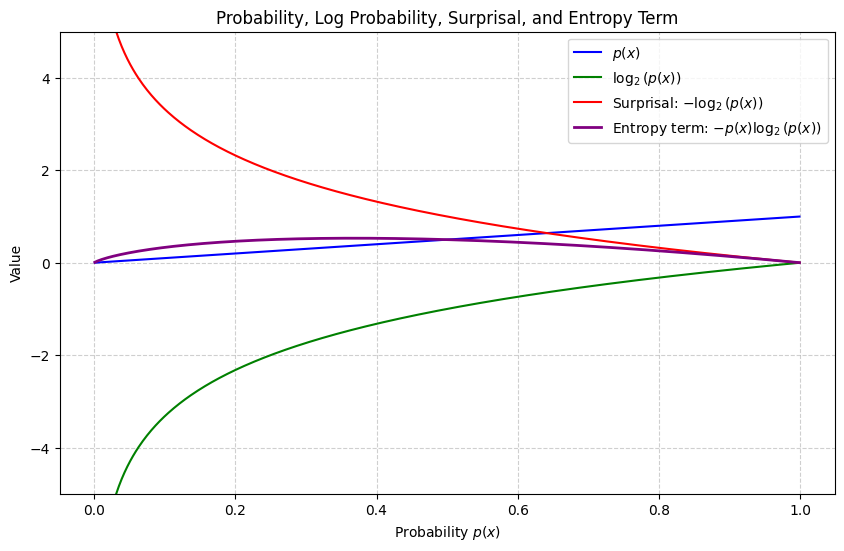

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Probability values
p = np.linspace(0.001, 0.999, 500)

# Functions
px = p
logp = np.log2(p)
surprisal = -np.log2(p)
entropy_term = -p * np.log2(p)

plt.figure(figsize=(10,6))

# Plot each curve
plt.plot(p, px, label=r"$p(x)$", color="blue")
plt.plot(p, logp, label=r"$\log_2(p(x))$", color="green")
plt.plot(p, surprisal, label=r"Surprisal: $-\log_2(p(x))$", color="red")
plt.plot(p, entropy_term, label=r"Entropy term: $-p(x)\log_2(p(x))$", color="purple", linewidth=2)

# Formatting
plt.title("Probability, Log Probability, Surprisal, and Entropy Term")
plt.xlabel("Probability $p(x)$")
plt.ylabel("Value")
plt.ylim(-5, 5)   # <-- Clip the y-axis to keep curves visible
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


# Information Theory and Cross-Entropy (2/5)  

**Coin flip intuition**  
- A fair coin: $H = 1$ bit → completely uncertain.  
- A biased coin: $H < 1$ bit → more predictable.  
- A certain coin: $H = 0$ → no uncertainty.  

**Question for students:**  
How uncertain is this coin flip?  


# Information Theory and Cross-Entropy (3/5)  

**Entropy as "Yes/No Questions"**  

- Think of uncertainty as the **average number of yes/no questions**  
  you need to ask to identify the outcome.  

- Example: "20 Questions" game.  
  - If answers are evenly split (yes/no = 50/50),  
    each question gives you 1 bit of information.  


# Information Theory and Cross-Entropy (4/5)  

**Uniform case → more questions**  
- Suppose 8 equally likely outcomes  
- It takes about $\log_2(8) = 3$ yes/no questions  
  (on average) to identify the outcome  

**Skewed case → fewer questions**  
- If one outcome is much more likely than others  
- Most of the time you guess it right in fewer questions  


# Information Theory and Cross-Entropy (5/5)  

**Key Idea**  
- Entropy = *average number of yes/no questions*  
  required to identify the outcome  

- Uniform distribution → maximum entropy (many questions)  
- Skewed distribution → lower entropy (fewer questions)  

Entropy measures **how much uncertainty remains** before the answer is known  


# Information-theoretic View (1/4)  

**Entropy recap**  
- Entropy $H(p)$ measures the average uncertainty  
  when outcomes follow the true distribution $p$  

$$
H(p) = - \sum_x p(x) \log p(x)
$$  

In theory: $p$ = the *true distribution*.  
In practice: we approximate $p$ using frequencies from **test data**.  


# Information-theoretic View (2/4)  

**In practice**  
- We don’t know the true distribution $p$ exactly  
- We approximate $p$ with a **held-out dataset** (test set)  
- We build a **model distribution** $m$ from training data  
- We then evaluate how well $m$ predicts data sampled from $p$  


# Information-theoretic View (3/4)  

**Cross-entropy definition**  

$$
H(p, m) = - \sum_x p(x) \log m(x)
$$  

- $p$: approximated by the empirical test distribution  
- $m$: model’s predicted probabilities  
- Measures the average uncertainty of real data ($p$)  
  under the model’s predictions ($m$)  


# Information-theoretic View (4/4)  

**Key idea**  
- Entropy $H(p)$ = baseline uncertainty (true $p$)  
- Cross-entropy $H(p, m)$ = uncertainty under model $m$  
- If $m = p$, then $H(p, m) = H(p)$  
- If $m \ne p$, then $H(p, m) > H(p)$  

In NLP: cross-entropy is estimated as the  
**average negative log-likelihood on test data**.  

Lower cross-entropy → better model approximation  


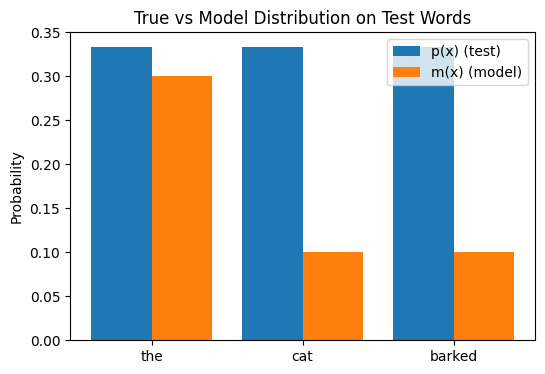

Entropy of test distribution H(p): 1.58 bits/word
Cross-Entropy H(p,m): 2.79 bits/word


In [9]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Training and test corpora
train_corpus = "the cat sat on the mat and the dog barked".split()
test_corpus = "the cat barked".split()

# Model distribution m(x) from training corpus
train_counts = Counter(train_corpus)
total_train = sum(train_counts.values())
m_probs = {w: c / total_train for w, c in train_counts.items()}

# "True" distribution p(x) from test corpus
test_counts = Counter(test_corpus)
total_test = sum(test_counts.values())
p_test = {w: c / total_test for w, c in test_counts.items()}

# Compute entropy of p and cross-entropy H(p,m)
entropy_p = -sum(p_test[w] * np.log2(p_test[w]) for w in p_test)
cross_entropy = -sum(p_test[w] * np.log2(m_probs.get(w, 1e-12)) for w in p_test)

# Visualization: compare distributions
words = list(p_test.keys())
x = np.arange(len(words))

plt.figure(figsize=(6,4))
plt.bar(x-0.2, [p_test[w] for w in words], width=0.4, label="p(x) (test)")
plt.bar(x+0.2, [m_probs.get(w,0) for w in words], width=0.4, label="m(x) (model)")
plt.xticks(x, words)
plt.ylabel("Probability")
plt.title("True vs Model Distribution on Test Words")
plt.legend()
plt.show()

# Print results
print(f"Entropy of test distribution H(p): {entropy_p:.2f} bits/word")
print(f"Cross-Entropy H(p,m): {cross_entropy:.2f} bits/word")


# Interpreting Cross-Entropy Results  

**From the example**  
- $H(p) =$ entropy of test distribution (baseline uncertainty)  
- $H(p,m) =$ cross-entropy of model vs. test (average surprisal)  

**Interpretation**  
- If $m(x)$ matches $p(x)$ → bars overlap → $H(p,m) \approx H(p)$  
- If $m(x)$ misestimates $p(x)$ → bars differ → $H(p,m) > H(p)$  
- The gap $H(p,m) - H(p)$ = extra cost for using the wrong model   


**Bigger picture (NLP)**  
- Cross-entropy = **average negative log-likelihood on test data**  
- Perplexity = $2^{H(p,m)}$ = “effective branching factor”  
- Lower cross-entropy / perplexity → better language model  

**Takeaway**  
Cross-entropy tells us *how well the model’s predicted distribution  
matches the true distribution of language (approximated by test data).* 

# Surprisal in Psycholinguistics (1/2)  

**Definition:**  
The **surprisal** of a word $w_i$ given its context is:  

$$
-\log P_m(w_i \mid \text{context})
$$  

**Interpretation:**  
- High surprisal → word was unexpected (low probability)  
- Low surprisal → word was expected (high probability)  

**Relevance:**  
Surprisal correlates with the amount of **cognitive effort** humans expend during sentence processing.


# Surprisal in Psycholinguistics (2/2)  

**Example sentence:**  
*"I drink my coffee with cream and **socks** in the morning when I get up."*  

Unexpected words (like *socks*) produce higher surprisal. This correlates with measurable cognitive effects:  

- **Longer reading times** (eye-tracking)  
- **Event-related potentials** (e.g., N400, P600 in EEG)  
- **Increased blood oxygen level** (fMRI)  

**Takeaway:**  
Computational language models can predict the **difficulty of human sentence processing**.


# N-gram Length and Performance  

### Does increasing N-gram length always improve language models?  

**Yes — but only up to a point.**  

- Longer context → more accurate conditional probabilities  
- But **data sparsity** grows quickly:  
  - Unigram: $O(V)$ parameters  
  - Bigram: $O(V^2)$ parameters  
  - Trigram: $O(V^3)$ parameters  
- Most higher-order n-grams will have **zero counts** in real data  

**Trade-off:**  
- Larger $N$ captures longer dependencies  
- But requires far more data to estimate reliably


### N-gram Tools and Resources

**"All Our N-gram are Belong to You"** (Reference to classic internet meme)

Popular N-gram modeling toolkits:

**KenLM**
- https://kheafield.com/code/kenlm/

**SRILM**  
- http://www.speech.sri.com/projects/srilm/

**Historical Reference: Google N-Gram Release, August 2006**

The slide shows a reference to Google's massive N-gram dataset release with the title "All Our N-gram are Belong to You" posted by the Google Research team. This was a significant release that provided:

- Enormous datasets of N-grams for a variety of NLP projects
- Counts for 1-grams through 5-grams extracted from a large web corpus
- Over 1 trillion tokens and over 13 million unique words
- This resource was foundational for many NLP research projects

The Google N-gram datasets served as the incoming 52 terms as the incubator 49 terms as the index 233, etc., providing crucial frequency statistics for language modeling research.

### Python-Native N-gram LM Toolkit: `nltk.lm`

For Python-based projects, NLTK ships a full language modelling module (`nltk.lm`) that handles preprocessing, smoothing, and evaluation without external C++ dependencies.

| Class | Smoothing method |
|-------|-----------------|
| `nltk.lm.MLE` | Maximum Likelihood (no smoothing) |
| `nltk.lm.Laplace` | Add-1 smoothing |
| `nltk.lm.Lidstone` | Add-k smoothing |
| `nltk.lm.KneserNeyInterpolated` | Interpolated Kneser-Ney |

**Key functions:**
- `padded_everygram_pipeline(n, sents)` — prepares training data with `<s>`/`</s>` padding  
- `model.fit(train_data, vocab)` — trains the model  
- `model.perplexity(text)` — evaluates on held-out text  
- `model.generate(n, text_seed=…)` — generates new tokens


In [10]:
# ============================================================
# Using nltk.lm — Python-native N-gram language modelling
# Source: https://www.nltk.org/api/nltk.lm.html
# ============================================================
import nltk
from nltk.lm import MLE, Laplace, KneserNeyInterpolated
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_sequence
from nltk.util import ngrams as nltk_ngrams
from nltk.corpus import brown

nltk.download("brown", quiet=True)

# ── Prepare data ───────────────────────────────────────────────────────
n = 2   # bigram
train_sents = [list(s) for s in brown.sents()[:2000]]
test_sents  = [list(s) for s in brown.sents()[2000:2010]]

# padded_everygram_pipeline: generates all n-grams up to order n
# with <s> / </s> padding and builds the vocabulary
train_data, vocab = padded_everygram_pipeline(n, train_sents)
train_data_kn, vocab_kn = padded_everygram_pipeline(n, train_sents)

# ── Fit models ────────────────────────────────────────────────────────
laplace_lm = Laplace(n)
laplace_lm.fit(train_data, vocab)

kn_lm = KneserNeyInterpolated(n)
kn_lm.fit(train_data_kn, vocab_kn)

# ── Perplexity: must pass n-grams, not flat words ─────────────────────
# model.perplexity() expects a list of (n-gram tuples), not raw words.
test_ngrams = []
for sent in test_sents:
    padded = list(pad_sequence(sent, n, pad_left=True, pad_right=True,
                               left_pad_symbol='<s>', right_pad_symbol='</s>'))
    test_ngrams.extend(nltk_ngrams(padded, n))

pp_laplace = laplace_lm.perplexity(test_ngrams)

# KN perplexity is inf if any OOV word is encountered with zero probability.
# This is a known limitation of nltk.lm — real systems use <UNK> tokens to handle OOV.
pp_kn = kn_lm.perplexity(test_ngrams)

print("Bigram LM perplexity on 10 held-out Brown sentences:")
print(f"  Laplace (Add-1) perplexity : {pp_laplace:.1f}")
print(f"  Kneser-Ney     perplexity  : {pp_kn}")
print()
if pp_kn == float('inf'):
    print("  Note: KN perplexity is inf because the test set contains out-of-vocabulary")
    print("  words that the model assigns probability 0. In production, OOV words are")
    print("  replaced with a special <UNK> token during both training and evaluation.")

# ── Word-level log-scores (more informative) ──────────────────────────
print()
print("Word-level log₂ scores for known vocabulary items:")
print(f"  {'Bigram':<35} {'Laplace':>13} {'Kneser-Ney':>13}")
print("  " + "─" * 63)

test_pairs = [
    ("the",    ("the",)),      # very common word in common context
    ("dog",    ("the",)),      # common bigram
    ("cat",    ("the",)),      # alternate word in same context
]
for word, ctx in test_pairs:
    la = laplace_lm.logscore(word, ctx)
    kn = kn_lm.logscore(word, ctx)
    print(f"  P({word:<17s}| {ctx[0]:<12s}) {la:>13.3f}   {kn:>10.3f}")

# ── Generate text ─────────────────────────────────────────────────────
print()
print("Generate 15 tokens (Laplace bigram, seed='The'):")
print(" ", " ".join(laplace_lm.generate(15, text_seed=["The"], random_seed=7)))

print()
print("Generate 15 tokens (Kneser-Ney bigram, seed='The'):")
print(" ", " ".join(kn_lm.generate(15, text_seed=["The"], random_seed=7)))


[nltk_data] Error loading brown: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


Bigram LM perplexity on 10 held-out Brown sentences:
  Laplace (Add-1) perplexity : 3471.7
  Kneser-Ney     perplexity  : inf

  Note: KN perplexity is inf because the test set contains out-of-vocabulary
  words that the model assigns probability 0. In production, OOV words are
  replaced with a special <UNK> token during both training and evaluation.

Word-level log₂ scores for known vocabulary items:
  Bigram                                    Laplace    Kneser-Ney
  ───────────────────────────────────────────────────────────────
  P(the              | the         )       -13.352      -10.144
  P(dog              | the         )       -13.352      -16.457
  P(cat              | the         )       -13.352         -inf

Generate 15 tokens (Laplace bigram, seed='The'):
  aged . </s> . </s> `` But it '' . </s> 1951 , the Giants'

Generate 15 tokens (Kneser-Ney bigram, seed='The'):


  administration . </s> . </s> anyone . </s> , but I announce the rains ,


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 3. Hidden Markov Models



# Hidden Markov Models  

### Sequence Modeling: HMMs  

Other sequence models in NLP include:  
- **Conditional Random Fields (CRFs):** Discriminative sequence models, learn $P(y \mid x)$ directly  
- **Structured Perceptrons:** Online learning for structured outputs  
- **Neural sequence models:** RNNs, LSTMs, Transformers — capture long-range dependencies  

**Why study HMMs?**  
- **Latent generative model:** hidden states explain observed words  
- **Dynamic programming:** efficient algorithms (Forward–Backward, Viterbi)  

HMMs are a foundation: simple enough to analyze, yet they introduce concepts used in modern models.  


# Noisy Channel Models

**Key idea:**  
- Messages pass through a noisy channel.  
- The receiver must **decode** the original message $T$ from the observed signal $W$.  

<p align="center">
  <img src="img/noisy_channel.png" alt="Noisy Channel Model" width="900"/>
</p>

- $P(T)$ → Prior probability of the original message  
- $P(W \mid T)$ → Probability of the noisy version given $T$  
- Decoder: chooses $\hat{T} = \arg\max_T P(T) \cdot P(W \mid T)$  


**Example (spelling correction):**  
Observed $W =$ "hte"  
- Candidate $T =$ "the"  
  - $P(T)$: "the" is very common in English  
  - $P(W \mid T)$: "hte" is a likely typo for "the"  
- Candidate $T =$ "hat"  
  - $P(T)$: also common, but  
  - $P(W \mid T)$: "hte" is an unlikely typo for "hat"  

Decoder picks **"the"** since it maximizes $P(T)\cdot P(W \mid T)$  


# Noisy Channel Models  

**Step 1: Decode using Bayes’ rule**  
Choose the most likely hidden message $T$:  

$$
\hat{T} = \arg\max_T P(T \mid W)
$$  
(*Which $T$ best explains the observed $W$?*)  

---

**Step 2: Expand with Bayes**  

$$
P(T \mid W) = \frac{P(T) \cdot P(W \mid T)}{P(W)}
$$  
(*Break posterior into prior × likelihood*)  

---

**Step 3: Drop $P(W)$ (same for all $T$)**  

$$
\hat{T} = \arg\max_T P(T) \cdot P(W \mid T)
$$  

- $P(T)$ → **Language model** (how natural is $T$?)  
- $P(W \mid T)$ → **Channel model** (how likely $W$ arises from $T$)  


**Applications in NLP:**  
- **Spelling correction**: recover intended word $T$ from a misspelled word $W$.  
- **Machine translation**: original sentence $T$ vs. translated words $W$.  
- **Speech recognition**: underlying text $T$ vs. noisy audio signal $W$.  

# Noisy Channel Models: Example  

### Task: Spell Correction  

Observed word: **"recieve"**  

Candidate set of possible true words $T$:  
- "receive"  
- "recipe"  
- "recede"  


# Step 1: Prior $P(T)$  

How frequent is each word?  

- $P(\text{receive})$ → high (common)  
- $P(\text{recipe})$ → lower  
- $P(\text{recede})$ → very small  


# Step 2: Channel $P(W \mid T)$  

How plausible is the typo "recieve"?  

- From "receive": very likely  
- From "recipe": less likely  
- From "recede": nearly impossible  


# Step 3: Combine  

Decoder chooses  

$$
\hat{T} = \arg\max_T P(T) \cdot P(W \mid T)
$$  

Result: **"receive"** wins.  


# Other NLP Tasks: Noisy Channel Model in Machine Translation  

We want to recover the original English sentence $T$  
given the observed French sentence $W$.  

$$
\hat{T} = \arg\max_T P(T) \cdot P(W \mid T)
$$  

- $P(T)$ = probability of the English sentence (language model)  
- $P(W \mid T)$ = probability that $T$ would generate the French $W$ (translation model)  

This is the classic “noisy channel” view of MT.  


# From Noisy Channel to HMMs  

We model the joint distribution as:  

$$
P(T, W) = \prod_i P(t_i \mid t_{i-1}) \; P(w_i \mid t_i)
$$  

**Why can we do this?**  
Because HMMs make two simplifying assumptions:  

1. **Markov assumption (states):**  
   Each hidden state $t_i$ depends only on the previous state $t_{i-1}$.  
   (*No long-distance dependencies among hidden states.*)  

2. **Emission assumption (observations):**  
   Each observed word $w_i$ depends only on its current hidden state $t_i$.  
   (*No direct dependence on other hidden states or observations.*)  

Together, these assumptions let us factorize the joint distribution into  
**transition probabilities × emission probabilities.**  

This decomposition = the core idea of a Hidden Markov Model.  


# Hidden vs. Observed in Machine Translation  

- **Observed ($W$):** foreign sentence (e.g., French: "je t’aime")  
- **Hidden ($T$):** original English sentence (e.g., "I love you")  

How it works:  
- Hidden English words follow a sequence model (transitions)  
- Each English word generates a French word (emissions)  

Goal: recover the hidden English sentence $T$  
that best explains the observed French words $W$.  


# Hidden vs. Observed in POS Tagging  

- **Observed ($W$):** sentence words (e.g., "the dog barked")  
- **Hidden ($T$):** part-of-speech tags (DET, NOUN, VERB)  

How it works:  
- Hidden POS tags follow a sequence model (transitions)  
- Each tag generates words with certain probabilities (emissions)  

Goal: recover the hidden tag sequence $T$  
that best explains the observed words $W$.  


# Hidden Markov Models  

### Step 2: Transition Probabilities 

$A = P(t_j \mid t_i)$  

- Probability of moving from one hidden state to the next  
- Example (POS tagging):  
  - $P(\text{Noun} \mid \text{DET})$ is high  
  - $P(\text{Verb} \mid \text{DET})$ is low  
- Captured in a **transition matrix**  


# Example: Transition Matrix  

$$
A = 
\begin{array}{c|ccccc}
 & \text{DET} & \text{Noun} & \text{Verb} & \text{Adj} & \text{END} \\
\hline
\text{START} & 0.6 & 0.3 & 0.1 & 0   & 0   \\
\text{DET}   & 0   & 0.7 & 0.1 & 0.2 & 0   \\
\text{Noun}  & 0   & 0.1 & 0.7 & 0.1 & 0.1 \\
\text{Verb}  & 0   & 0.6 & 0.1 & 0   & 0.3 \\
\text{Adj}   & 0   & 0.8 & 0.1 & 0.1 & 0   \\
\end{array}
$$  

- **Rows = current hidden state**  
- **Columns = next hidden state**  
- Each row sums to 1 (probability distribution)  
- Estimated from corpus counts  
  - e.g., $P(\text{Noun} \mid \text{DET}) = 
    \dfrac{\#(\text{DET}\to \text{Noun})}{\#(\text{DET})}$  

**Interpretation**  
- DET is usually followed by Noun (0.7)  
- Noun is often followed by Verb (0.7)  
- Verb can end the sentence (0.3)  


# Hidden Markov Models  

### Step 2: Transition Probabilities  

$$
A = P(t_j \mid t_i)
$$  

- Probability of moving from one hidden state to the next  
- Example: DET → Noun is likely; Noun → Verb is also common  
- Encoded in a **transition matrix**  


# Hidden Markov Models  

### Step 3: Emission Probabilities  


$B = P(w_k \mid t_i)$  

- Probability of observing word $w_k$ given hidden state $t_i$  
- Example (POS tagging):  
  - If $t_i = \text{Noun}$ → "dog", "cat", "zoo" have high probability  
  - If $t_i = \text{Verb}$ → "barked", "ran", "eat" have high probability  
- Captured in an **emission matrix**  
  


# Example: Emission Matrix  

$$
B =
\begin{array}{c|cccc}
      & \text{dog} & \text{cat} & \text{barked} & \text{ran} \\ \hline
\text{Noun} & 0.4 & 0.4 & 0.1 & 0.1 \\
\text{Verb} & 0.0 & 0.0 & 0.6 & 0.4 \\
\text{DET}  & 0.0 & 0.0 & 0.0 & 0.0 \\
\end{array}
$$  

- **Rows = hidden states (tags)**  
- **Columns = observed words**  
- Each row sums to 1 (distribution over words given a state)  
- Estimated from corpus counts  
  - e.g., $P(\text{dog} \mid \text{Noun}) = 
    \dfrac{\#(\text{Noun emits "dog"})}{\#(\text{Noun})}$  

**Interpretation**  
- Noun emits "dog" or "cat" most often (0.4 each)  
- Verb emits "barked" (0.6) and "ran" (0.4)  
- DET never emits these words (all zeros)  


# Hidden Markov Models  

### Step 4: The Full Model  

An HMM is fully defined by three components:  

1. **Transition matrix $A$**  
   $A = P(t_j \mid t_i)$  
   - Probability of moving from one hidden state to the next  

2. **Emission matrix $B$**  
   $B = P(w_k \mid t_i)$  
   - Probability of observing word $w_k$ given hidden state $t_i$  

3. **Initial distribution $\pi$**  
   $\pi = P(t_1)$  
   - Probability of starting in each hidden state  

**Together ($A$, $B$, $\pi$):**  
- Describe how hidden states evolve over time  
- And how they generate the observed sequence of words  


# Hidden Markov Models  

### Step 4: The Full Model  

An HMM is fully defined by three components:  

1. **Transition matrix $A$**  
   $A = P(t_j \mid t_i)$  
   - Probability of moving from one hidden state to the next  

2. **Emission matrix $B$**  
   $B = P(w_k \mid t_i)$  
   - Probability of observing word $w_k$ given hidden state $t_i$  

3. **Initial distribution $\pi$**  
   $\pi = P(t_1)$  
   - Probability of starting in each hidden state  
   - Example: in a tagged corpus,  
     $P(\text{DET at position 1}) = 0.6$,  
     $P(\text{Noun at position 1}) = 0.3$,  
     $P(\text{Verb at position 1}) = 0.1$  

**Together ($A$, $B$, $\pi$):**  
- Describe how hidden states evolve over time  
- And how they generate the observed sequence of words  


# Hidden Markov Models  

### Step 6: Decoding (Inference)  

Given a new sentence:  
*"the dog barked loudly"*  

- **Observed words**:  
  $W = (w_1, w_2, w_3, w_4)$  

- **Hidden tags**:  
  $T = (t_1, t_2, t_3, t_4)$  

**Problem:** The hidden tag sequence is unknown.  

If there are 12 possible tags:  
- Each position has 12 options  
- For 4 words → $12^4 = 20{,}736$ possible sequences  
- For 20 words → $12^{20}$ (astronomically large)  



# Inference in HMMs  

Once the model is trained, we often need to do **inference**:  
figure out hidden states or sequence probabilities.  

### Main methods
- **Forward algorithm**  
  - Computes the total probability of the observed sequence  
  - Complexity: $O(N^2 T)$  

- **Viterbi algorithm**  
  - Finds the *single most likely* sequence of hidden states  
  - Complexity: $O(N^2 T)$  

- **Forward–Backward algorithm**  
  - Combines past (forward) and future (backward) info  
  - Used to compute state probabilities and in training (Baum–Welch)  
  - Complexity: $O(N^2 T)$  

---

**Key idea:**  
- Brute force decoding = $O(N^T)$ (exponential)  
- Dynamic programming = $O(N^2 T)$ (polynomial, tractable)  


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# Appendix



# Decoding HMMs with Dynamic Programming (1/2)

### Forward Probability Intuition

We want the probability of being in state $a_j$ at time $t$ 
after generating the first $t$ observations.  
This is called the **forward probability** $\alpha_t(j)$.




<img src="img/decoding_hmm.png" alt="HMM Decoding" width="500"/>
- Rows = hidden states $a_1, a_2, \dots, a_N$  
- Columns = observed sequence $O_1, O_2, \dots, O_T$  
- Each path through the grid corresponds to a possible state sequence.



### Recurrence

- **Initialization:**  
  $\alpha_1(\text{START}) = 1$  

- **Recursive step:**  
  $\alpha_t(j) = \sum_{i=1}^N \alpha_{t-1}(i)\, a_{ij}\, b_j(O_t)$  

where  
- $a_{ij}$ = transition probability from state $i$ to $j$  
- $b_j(O_t)$ = probability of emitting observation $O_t$ from state $j$

# Decoding HMMs with Dynamic Programming (2/2)

### Goal
Find the **highest probability path** of hidden states 
$a_1, a_2, \dots, a_T$ that generates the observations 
$O_1, O_2, \dots, O_T$, given HMM $(A, B, \pi)$.

---

### Key Question
What is the probability of a single candidate path?

For states $S_0, S_1, S_2, \dots$ and observations $O_1, O_2, \dots$:

$$
P(S_0) \cdot P(S_1 \mid S_0) \cdot P(O_1 \mid S_1) \cdot
P(S_2 \mid S_1) \cdot P(O_2 \mid S_2) \cdot \dots
$$

---

### Components
- **Transition probability**: $a_{s_{t-1}s_t}$ from matrix $A$  
- **Emission probability**: $b_{s_t}(O_t)$ from matrix $B$  
- **Initial probability**: $\pi(S_0)$

---

### Clarification
- The Forward algorithm: **sums over all paths**.  
- Viterbi algorithm: **selects the single most probable path** 
  (replace $\sum$ with $\max$ in the recurrence).


# Brute Force vs. Dynamic Programming

### Example: "the dog"
- Observations: $O_1 = \text{"the"}, \; O_2 = \text{"dog"}$
- Hidden states: DET, NOUN

---

### 🚫 Brute Force (no DP)
List **all possible state paths** (4 in total):

1. DET → DET  
   $\pi(\text{DET}) \, b_{\text{DET}}(O_1) \, a_{\text{DET}\to\text{DET}} \, b_{\text{DET}}(O_2)$  

2. DET → NOUN  
   $\pi(\text{DET}) \, b_{\text{DET}}(O_1) \, a_{\text{DET}\to\text{NOUN}} \, b_{\text{NOUN}}(O_2)$  

3. NOUN → DET  
   $\pi(\text{NOUN}) \, b_{\text{NOUN}}(O_1) \, a_{\text{NOUN}\to\text{DET}} \, b_{\text{DET}}(O_2)$  

4. NOUN → NOUN  
   $\pi(\text{NOUN}) \, b_{\text{NOUN}}(O_1) \, a_{\text{NOUN}\to\text{NOUN}} \, b_{\text{NOUN}}(O_2)$  

- Need to sum all 4 → exponential growth: $N^T$ paths  

---

### ✅ Dynamic Programming (Forward Algorithm)
Collapse paths ending in the same state:

- Initialization ($t=1$):  
  $\alpha_1(\text{DET}) = \pi(\text{DET}) \cdot b_{\text{DET}}(O_1)$  
  $\alpha_1(\text{NOUN}) = \pi(\text{NOUN}) \cdot b_{\text{NOUN}}(O_1)$  

- Recursion ($t=2$):  
  $\alpha_2(\text{DET}) =$ (paths 1 + 3 combined)  
  $\alpha_2(\text{NOUN}) =$ (paths 2 + 4 combined)  

- Only 2 numbers to carry at $t=2$ (one per state)  
- Complexity drops to $O(N^2T)$ (polynomial)  


# HMM as a Graphical Model

### Key Ideas
- Arrows represent **conditional dependencies**  
- Each hidden state $T_j$ depends **only on the previous state** $T_{j-1}$  
- Each observed word $W_i$ depends **only on its corresponding state** $T_i$  

---

### Graphical Structure

<img src="img/graphical_model.png" alt="HMM Graphical Model" width="550"/>

- Top row: hidden states $T_1, T_2, \dots, T_n$  
- Bottom row: observed words $W_1, W_2, \dots, W_n$  
- Captures the **Markov assumption** and **emission assumption**.  


# CRF as a Graphical Model

### Linear-chain Conditional Random Field

- **Discriminative**, not generative  
- **Undirected graph** representation  
- **Log-linear model** (uses weighted feature functions)  
- Entire observed input $X = (x_1, x_2, \dots, x_n)$  
  is available to the feature functions $F_j$  
- Only **local parts of $Y$** (neighboring labels) 
  are considered at each step → Markov assumption  

---

### Visualization

<img src="img/linear_chain_crf.png" alt="Linear-chain CRF" width="550"/>

---

### Probability Formulation

$P(Y \mid X; \mathbf{w}) = 
\frac{\exp\big(\mathbf{w} \cdot \mathbf{F}(X,Y)\big)}
{\sum_Y \exp\big(\mathbf{w} \cdot \mathbf{F}(X,Y)\big)}$

where  

$F_j(X,Y) = \sum_i F_j(y_{i-1}, y_i, X, i)$


---

## Viterbi Algorithm — Code Implementation

The slides above explain the Viterbi algorithm conceptually using the DP trellis.  
Now let's implement it from scratch for a toy POS-tagging problem and visualise the trellis.

**Recall the goal:**  
Given observed words $W = (w_1, \dots, w_T)$, find the hidden state (POS tag) sequence $\hat{T}$ that maximises $P(T, W)$:

$$\hat{T} = \arg\max_T \prod_{i=1}^{T} P(t_i \mid t_{i-1}) \cdot P(w_i \mid t_i)$$

The DP recurrence (Viterbi):

$$v_t(j) = \max_{i} \bigl[ v_{t-1}(i) \cdot A_{ij} \cdot B_{j}(w_t) \bigr]$$


Input observation:   ['the', 'dog', 'barked']
Viterbi POS path:    ['DET', 'NOUN', 'VERB']

Word         Tag      Max Path Probability
──────────────────────────────────────────
  the        DET      4.2000e-01
  dog        NOUN     2.0097e-01
  barked     VERB     1.0270e-01


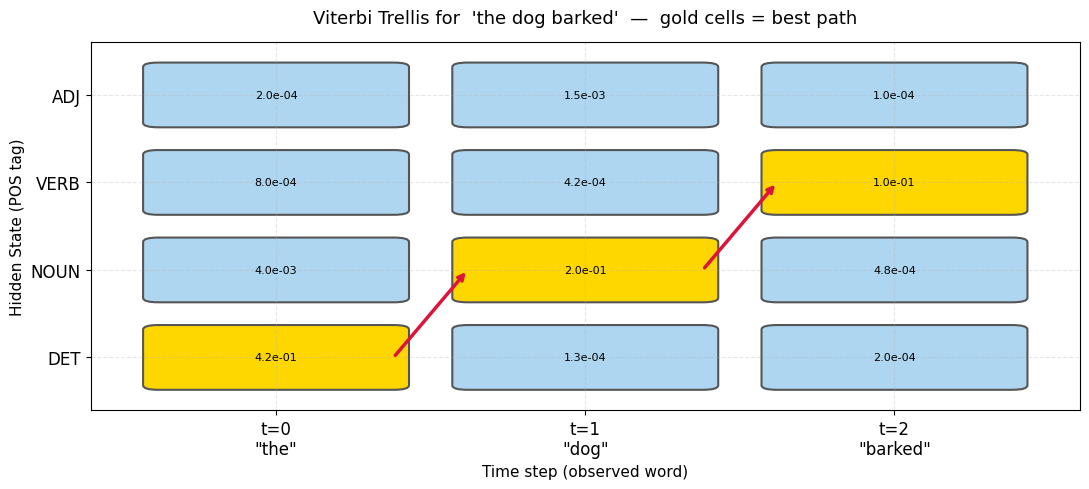

Red arrows trace the Viterbi-optimal path through the trellis.


In [11]:
# ============================================================
# Viterbi Algorithm — Toy POS Tagging
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# ── Toy HMM parameters ────────────────────────────────────────────────
states = ['DET', 'NOUN', 'VERB', 'ADJ']
obs    = ['the', 'dog', 'barked']

# π  Initial state probabilities (which tag starts a sentence?)
start_p = {'DET': 0.70, 'NOUN': 0.20, 'VERB': 0.08, 'ADJ': 0.02}

# A  Transition probabilities P(next_tag | current_tag)
trans_p = {
    'DET' : {'DET': 0.01, 'NOUN': 0.87, 'VERB': 0.05, 'ADJ': 0.07},
    'NOUN': {'DET': 0.10, 'NOUN': 0.12, 'VERB': 0.73, 'ADJ': 0.05},
    'VERB': {'DET': 0.38, 'NOUN': 0.33, 'VERB': 0.20, 'ADJ': 0.09},
    'ADJ' : {'DET': 0.05, 'NOUN': 0.80, 'VERB': 0.10, 'ADJ': 0.05},
}

# B  Emission probabilities P(word | tag)
emit_p = {
    'DET' : {'the': 0.60, 'a': 0.28, 'dog': 0.03, 'barked': 0.01, 'big': 0.08},
    'NOUN': {'the': 0.02, 'a': 0.01, 'dog': 0.55, 'barked': 0.02, 'big': 0.04, 'cat': 0.36},
    'VERB': {'the': 0.01, 'a': 0.01, 'dog': 0.02, 'barked': 0.70, 'big': 0.01, 'ran': 0.25},
    'ADJ' : {'the': 0.01, 'a': 0.01, 'dog': 0.05, 'barked': 0.01, 'big': 0.80, 'old': 0.12},
}

# ── Viterbi algorithm ─────────────────────────────────────────────────
def viterbi(obs, states, start_p, trans_p, emit_p):
    """
    Viterbi decoding.

    Parameters
    ----------
    obs      : list of observed words
    states   : list of hidden states (POS tags)
    start_p  : dict  {state → initial probability}
    trans_p  : dict  {from_state → {to_state → probability}}
    emit_p   : dict  {state → {word → probability}}

    Returns
    -------
    path      : most likely sequence of states
    dp        : full DP table (list of dicts, one per time step)
    backtrack : backpointer table
    """
    T = len(obs)
    dp        = [{} for _ in range(T)]   # dp[t][s]  = max log-prob to reach s at time t
    backtrack = [{} for _ in range(T)]   # backtrack[t][s] = best previous state

    eps = 1e-300   # small constant to avoid log(0)

    # ── Initialise (t = 0) ────────────────────────────────────────────
    for s in states:
        dp[0][s]        = start_p.get(s, eps) * emit_p.get(s, {}).get(obs[0], eps)
        backtrack[0][s] = None

    # ── Fill DP table ─────────────────────────────────────────────────
    for t in range(1, T):
        for s in states:
            best_prob, best_prev = max(
                (dp[t-1][prev] * trans_p.get(prev, {}).get(s, eps), prev)
                for prev in states
            )
            dp[t][s]        = best_prob * emit_p.get(s, {}).get(obs[t], eps)
            backtrack[t][s] = best_prev

    # ── Backtrace ─────────────────────────────────────────────────────
    best_last = max(states, key=lambda s: dp[T-1][s])
    path = [best_last]
    for t in range(T - 1, 0, -1):
        path.insert(0, backtrack[t][path[0]])

    return path, dp, backtrack

# ── Run ───────────────────────────────────────────────────────────────
path, dp, backtrack = viterbi(obs, states, start_p, trans_p, emit_p)

print("Input observation:  ", obs)
print("Viterbi POS path:   ", path)
print()
print(f"{'Word':<12} {'Tag':<8} {'Max Path Probability':}")
print("─" * 42)
for word, tag, dp_t in zip(obs, path, dp):
    print(f"  {word:<10} {tag:<8} {dp_t[tag]:.4e}")

# ── Visualise the DP trellis ─────────────────────────────────────────
T = len(obs)
N = len(states)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(-0.6, T - 0.4)
ax.set_ylim(-0.6, N - 0.4)
ax.set_xticks(range(T))
ax.set_xticklabels([f't={t}\n\"{w}\"' for t, w in enumerate(obs)], fontsize=12)
ax.set_yticks(range(N))
ax.set_yticklabels(states, fontsize=12)
ax.set_xlabel("Time step (observed word)", fontsize=11)
ax.set_ylabel("Hidden State (POS tag)",    fontsize=11)
ax.set_title("Viterbi Trellis for  \'the dog barked\'  —  gold cells = best path",
             fontsize=13, pad=14)
ax.grid(True, linestyle='--', alpha=0.3)

for t in range(T):
    for si, s in enumerate(states):
        on_path = (s == path[t])
        color   = '#FFD700' if on_path else '#AED6F1'   # gold / light-blue
        rect = mpatches.FancyBboxPatch(
            (t - 0.38, si - 0.32), 0.76, 0.64,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor='#555', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(t, si, f'{dp[t][s]:.1e}',
                ha='center', va='center', fontsize=8)

# Draw best-path transitions
for t in range(1, T):
    s_cur  = path[t];     si_cur  = states.index(s_cur)
    s_prev = path[t - 1]; si_prev = states.index(s_prev)
    ax.annotate(
        '', xy=(t - 0.38, si_cur), xytext=(t - 1 + 0.38, si_prev),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=2.5))

plt.tight_layout()
plt.show()
print("Red arrows trace the Viterbi-optimal path through the trellis.")


---

## Named Entity Recognition (NER) and BIO Tagging

NER is the task of identifying and classifying **named entities** in text:  
people, organisations, locations, dates, etc.

### BIO Tagging Scheme

Entities are represented using the **BIO** (or IOB2) notation applied to every token:

| Tag | Meaning |
|-----|---------|
| **B-TYPE** | **B**eginning of an entity of type TYPE |
| **I-TYPE** | **I**nside (continuation) of an entity of type TYPE |
| **O** | **O**utside any entity |

**Example:**  
*"Barack Obama was born in Honolulu, Hawaii"*  

| Token | Tag |
|-------|-----|
| Barack | B-PERSON |
| Obama | I-PERSON |
| was | O |
| born | O |
| in | O |
| Honolulu | B-GPE |
| , | O |
| Hawaii | B-GPE |

### Why HMMs (and CRFs) are natural here

- **Hidden states** = BIO entity tags  
- **Observed symbols** = words  
- The transition structure enforces valid BIO sequences  
  (e.g., an I-PERSON tag can only follow B-PERSON or I-PERSON)

> **Modern NER** uses pre-trained transformer models (BERT, RoBERTa) fine-tuned on  
> annotated corpora (CoNLL-2003, OntoNotes 5.0), but the BIO tagging scheme is universal.


In [12]:
# ============================================================
# NER with BIO Tags using spaCy (en_core_web_sm)
# Source: https://spacy.io/usage/linguistic-features#named-entities
# ============================================================
import subprocess, sys

try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
                   check=True)
    import spacy
    nlp = spacy.load("en_core_web_sm")

# ── Example sentence ──────────────────────────────────────────────────
text = ("Barack Obama was born in Honolulu, Hawaii, "
        "and served as the 44th President of the United States.")

doc = nlp(text)

# ── Show detected entities ────────────────────────────────────────────
print("Detected named entities:")
for ent in doc.ents:
    print(f"  {ent.text:<30s}  [{ent.label_:<10s}]  {spacy.explain(ent.label_)}")

print()

# ── BIO tag table ─────────────────────────────────────────────────────
print(f"{'Token':<18} {'BIO Tag':<15} {'Description'}")
print("─" * 55)
for token in doc:
    if token.ent_iob_ == 'O':
        bio_tag  = 'O'
        desc     = '—'
    elif token.ent_iob_ == 'B':
        bio_tag  = f'B-{token.ent_type_}'
        desc     = f'Begin {spacy.explain(token.ent_type_)}'
    else:   # 'I'
        bio_tag  = f'I-{token.ent_type_}'
        desc     = f'Inside {spacy.explain(token.ent_type_)}'
    print(f"  {token.text:<16} {bio_tag:<15} {desc}")

print()
print("Note: spaCy uses a statistical model trained on OntoNotes 5.0.")
print("Modern high-accuracy NER (F1 > 0.92 on CoNLL-2003) uses BERT-based models.")


Detected named entities:
  Barack Obama                    [PERSON    ]  People, including fictional
  Honolulu                        [GPE       ]  Countries, cities, states
  Hawaii                          [GPE       ]  Countries, cities, states
  44th                            [ORDINAL   ]  "first", "second", etc.
  the United States               [GPE       ]  Countries, cities, states

Token              BIO Tag         Description
───────────────────────────────────────────────────────
  Barack           B-PERSON        Begin People, including fictional
  Obama            I-PERSON        Inside People, including fictional
  was              O               —
  born             O               —
  in               O               —
  Honolulu         B-GPE           Begin Countries, cities, states
  ,                O               —
  Hawaii           B-GPE           Begin Countries, cities, states
  ,                O               —
  and              O               —
  serv

---

## Summary & Key Takeaways

### What We Covered

| Concept | Core Formula / Idea | Application |
|---------|---------------------|-------------|
| **Chain Rule** | $P(w_1\dots w_n) = \prod P(w_i\mid w_1\dots w_{i-1})$ | Exact sentence probability |
| **Markov Assumption** | $P(w_i\mid\text{history}) \approx P(w_i\mid w_{i-N+1}\dots w_{i-1})$ | N-gram models |
| **Perplexity** | $PP(W) = P(W)^{-1/N}$ | LM evaluation (lower = better) |
| **Cross-Entropy** | $H(p,m) = -\sum p(x) \log m(x)$ | Training objective |
| **Laplace Smoothing** | $P(w_i\mid w_{i-1}) = \frac{C(w_{i-1},w_i)+1}{C(w_{i-1})+V}$ | Simple zero-prob fix |
| **Kneser-Ney** | Discount + continuation probability | Best classical smoothing |
| **Noisy Channel** | $\hat{T} = \arg\max_T P(T)\cdot P(W\mid T)$ | Decoding (spelling, MT, ASR) |
| **HMM** | $P(T,W) = \prod P(t_i\mid t_{i-1})\cdot P(w_i\mid t_i)$ | Sequence labelling |
| **Viterbi** | DP: $v_t(j) = \max_i \bigl[v_{t-1}(i)\cdot A_{ij}\cdot B_j(w_t)\bigr]$ | Efficient HMM decoding |
| **BIO Tagging** | B-TYPE / I-TYPE / O | NER, chunking |

---

### Why This Still Matters in 2025–2026

- **Perplexity** remains the primary metric for comparing language models  
  (GPT-4, Claude, Llama, etc. are all evaluated this way)  
- **BIO tagging** is universal across all modern NER systems,  
  including transformer-based models fine-tuned on CoNLL-2003  
- **The Viterbi algorithm** is the basis for decoding in HMMs, CRFs,  
  and contributes to the intuition behind beam search in neural MT  
- **Kneser-Ney** is still the default smoothing in KenLM and remains  
  a strong baseline when data is scarce  
- The **noisy channel framing** (prior × likelihood) is the conceptual  
  ancestor of modern encoder-decoder and RAG architectures

---

### Recommended Reading

- Jurafsky & Martin (3rd ed.), **Chapter 3**: N-gram Language Models  
- Jurafsky & Martin (3rd ed.), **Chapter 8**: Sequence Labelling for Parts of Speech and NER  
- Chen & Goodman (1999): *"An Empirical Study of Smoothing Techniques for Language Modeling"*  
  — the paper that established Kneser-Ney as the gold standard  
- [NLTK LM documentation](https://www.nltk.org/api/nltk.lm.html)  
- [spaCy NER guide](https://spacy.io/usage/linguistic-features#named-entities)
